# Asasmen Tengah Semester - RE603 Machine Learning

**Nama:** Gabriel Simanjuntak 

**NIM:** 4222301050

**Kelas:** Robotika Pagi B


**1.NIM dengan nomor urut 11-20 mengerjakan studi kasus 2**

**Adit, pemilik sebuah perusahaan XYZ, ingin meningkatkan efisiensi proses rekrutmen dan pengelolaan SDM. Selama ini, penentuan gaji untuk calon karyawan masih dilakukan secara subjektif, yang berisiko menimbulkan ketimpangan dan ketidakadilan. Oleh karena itu, Adit dan tim HR ingin membangun sistem berbasis data untuk memprediksi gaji karyawan baru secara lebih objektif dan adil.**
**Dataset historis yang dimiliki perusahaan berisi informasi mengenai usia karyawan, lama bekerja, status karyawan (pria/wanita), dan departemen tempat bekerja, serta gaji bulanan yang diterima yang bisa dilihat di dataset_karyawan_missing.csv.**
**Bantulah Adit untuk menyelesaikan masalahnya.**

In [1]:
#Random Forest Regressor Method#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

c:\Users\ASUS TUF GAMING\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 1. Load Dataset

In [2]:
df = pd.read_csv('dataset_karyawan_missing.csv')
df.head(10)

,ID,Nama,Departemen,Gaji,Usia,Lama_Kerja,Status_Karyawan
0,1,Citra,NaN,5744870.0,53,9,Kontrak
1,2,Eka,HRD,5862014.0,39,9,Tetap
2,3,Citra,HRD,4894992.0,55,16,Tetap
3,4,Budi,QC,4606286.0,51,2,Kontrak
4,5,Dewi,HRD,4199766.0,44,7,Kontrak
5,6,Citra,Produksi,5139075.0,41,22,Kontrak
6,7,Dewi,QC,3651198.0,44,16,Kontrak
7,8,Budi,Produksi,5571161.0,29,19,Kontrak
8,9,Budi,NaN,5033255.0,35,6,Tetap
9,10,Andi,Logistik,5212685.0,44,20,Tetap


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               200 non-null    int64  
 1   Nama             200 non-null    object 
 2   Departemen       190 non-null    object 
 3   Gaji             190 non-null    float64
 4   Usia             200 non-null    int64  
 5   Lama_Kerja       200 non-null    int64  
 6   Status_Karyawan  200 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 11.1+ KB


In [4]:
df.isnull().sum()

ID                  0
Nama                0
Departemen         10
Gaji               10
Usia                0
Lama_Kerja          0
Status_Karyawan     0
dtype: int64

## 2. Eksplorasi Data

In [5]:
df.describe()

,ID,Gaji,Usia,Lama_Kerja
count,200.000000,1.900000e+02,200.000000,200.000000
mean,100.500000,5.053853e+06,41.545000,14.455000
std,57.879185,7.778678e+05,10.367517,8.277716
min,1.000000,2.786682e+06,22.000000,0.000000
25%,50.750000,4.594828e+06,34.000000,7.750000
50%,100.500000,5.040414e+06,42.000000,15.000000
75%,150.250000,5.602506e+06,49.250000,21.000000
max,200.000000,6.941904e+06,59.000000,29.000000


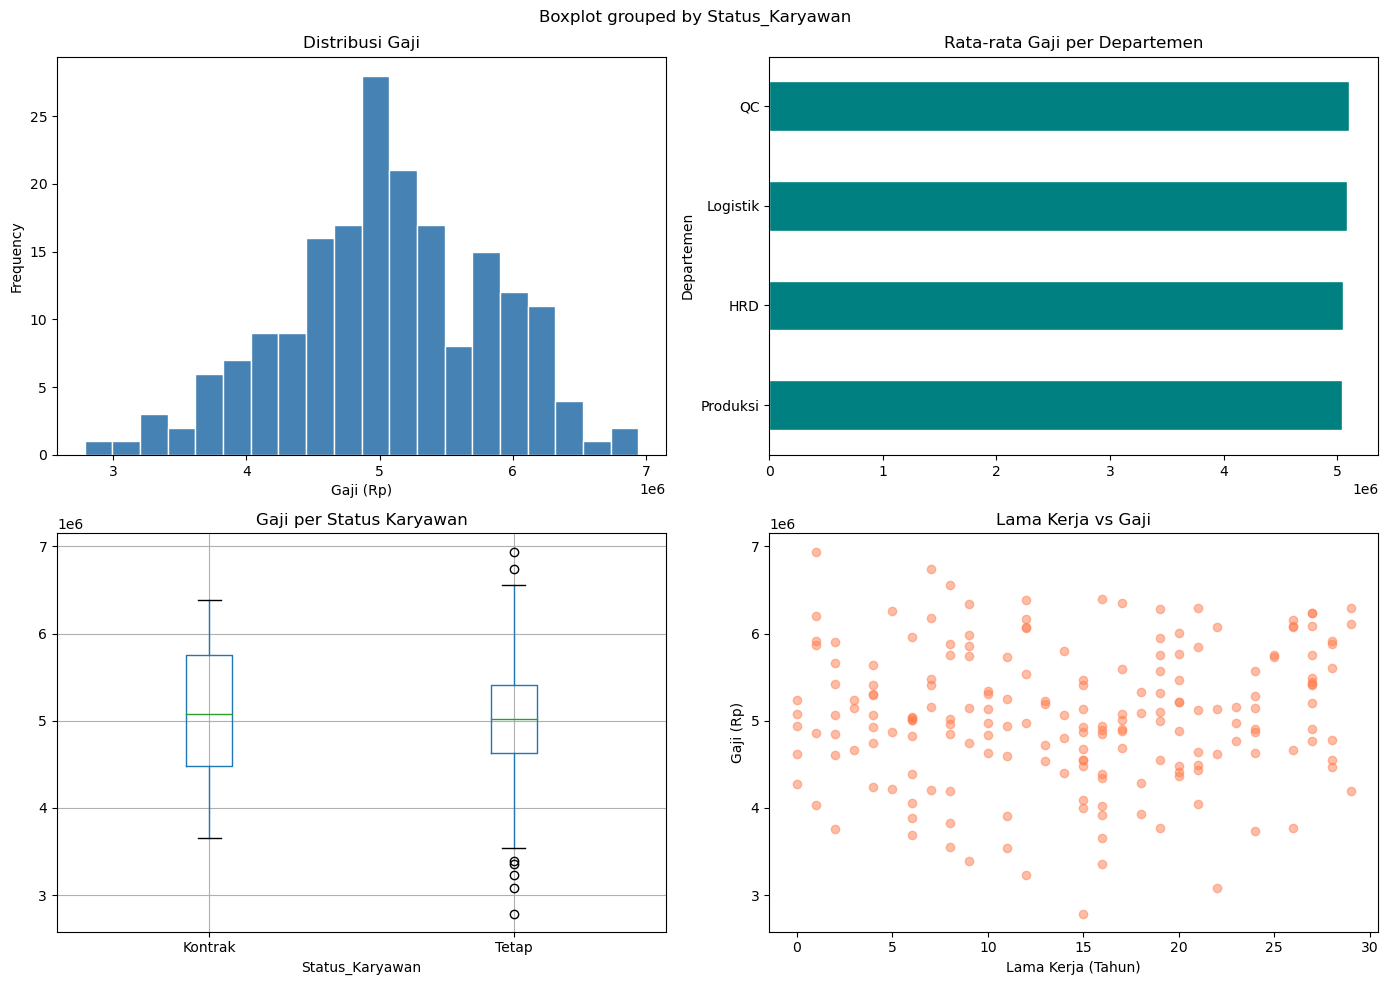

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df['Gaji'].dropna().plot(kind='hist', bins=20, ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribusi Gaji')
axes[0,0].set_xlabel('Gaji (Rp)')

df.dropna(subset=['Gaji','Departemen']).groupby('Departemen')['Gaji'].mean().sort_values().plot(
    kind='barh', ax=axes[0,1], color='teal', edgecolor='white')
axes[0,1].set_title('Rata-rata Gaji per Departemen')

df.dropna(subset=['Gaji']).boxplot(column='Gaji', by='Status_Karyawan', ax=axes[1,0])
axes[1,0].set_title('Gaji per Status Karyawan')
plt.sca(axes[1,0])
plt.title('Gaji per Status Karyawan')

df_clean = df.dropna(subset=['Gaji'])
axes[1,1].scatter(df_clean['Lama_Kerja'], df_clean['Gaji'], alpha=0.5, color='coral')
axes[1,1].set_title('Lama Kerja vs Gaji')
axes[1,1].set_xlabel('Lama Kerja (Tahun)')
axes[1,1].set_ylabel('Gaji (Rp)')

plt.tight_layout()
plt.show()

## 3. Preprocessing

In [7]:
df = df.drop(columns=['ID', 'Nama'])

df['Departemen'] = df['Departemen'].fillna(df['Departemen'].mode()[0])

df = pd.get_dummies(df, columns=['Departemen', 'Status_Karyawan'])

df.head()

,Gaji,Usia,Lama_Kerja,Departemen_HRD,Departemen_Logistik,Departemen_Produksi,Departemen_QC,Status_Karyawan_Kontrak,Status_Karyawan_Tetap
0,5744870.0,53,9,True,False,False,False,True,False
1,5862014.0,39,9,True,False,False,False,False,True
2,4894992.0,55,16,True,False,False,False,False,True
3,4606286.0,51,2,False,False,False,True,True,False
4,4199766.0,44,7,True,False,False,False,True,False


In [8]:
df_train = df[df['Gaji'].notna()].copy()
df_new   = df[df['Gaji'].isna()].copy()

print(f'Data training  : {len(df_train)}')
print(f'Data diprediksi: {len(df_new)}')

Data training  : 190
Data diprediksi: 10


In [9]:
X = df_train.drop(columns=['Gaji'])
y = df_train['Gaji']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 152 | Test: 38


## 4. Training Model - Random Forest

In [10]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 5. Evaluasi Model

In [11]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f'MAE  : Rp {mae:,.0f}')
print(f'RMSE : Rp {rmse:,.0f}')
print(f'R²   : {r2:.4f}')

MAE  : Rp 667,746
RMSE : Rp 881,859
R²   : -0.2698


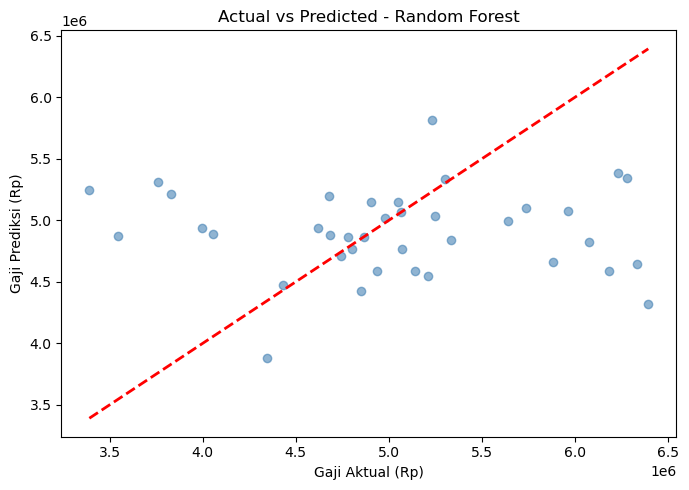

In [12]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Gaji Aktual (Rp)')
plt.ylabel('Gaji Prediksi (Rp)')
plt.title('Actual vs Predicted - Random Forest')
plt.tight_layout()
plt.show()

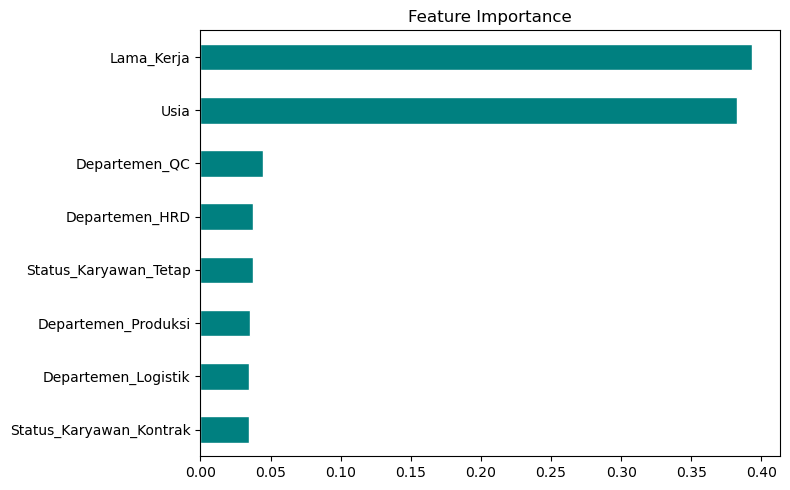

In [13]:
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feat_imp.plot(kind='barh', color='teal', edgecolor='white')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

## 6. Prediksi Gaji Karyawan Baru

In [14]:
X_new          = df_new.drop(columns=['Gaji'])
predicted_gaji = model.predict(X_new)

df_original = pd.read_csv('dataset_karyawan_missing.csv')
df_hasil    = df_original[df_original['Gaji'].isna()][['ID','Nama','Departemen','Usia','Lama_Kerja','Status_Karyawan']].copy()
df_hasil['Prediksi_Gaji'] = predicted_gaji.astype(int)

df_hasil

,ID,Nama,Departemen,Usia,Lama_Kerja,Status_Karyawan,Prediksi_Gaji
15,16,Dewi,Logistik,30,24,Kontrak,4920411
40,41,Citra,Produksi,45,27,Tetap,5633196
49,50,Dewi,HRD,33,19,Kontrak,5457242
54,55,Andi,HRD,48,15,Tetap,4878072
63,64,Andi,Produksi,43,4,Kontrak,4769922
70,71,Eka,Produksi,38,23,Tetap,4951087
73,74,Andi,HRD,41,24,Kontrak,4686998
82,83,Dewi,QC,54,20,Tetap,5013625
161,162,Eka,QC,46,4,Tetap,5288346
195,196,Dewi,Logistik,58,14,Kontrak,4980035


In [15]:
print('=' * 70)
print(f"{'ID':<5} {'Nama':<8} {'Departemen':<12} {'Usia':>5} {'Lama Kerja':>11} {'Status':<10} {'Prediksi Gaji':>15}")
print('=' * 70)
for _, row in df_hasil.iterrows():
    print(f"{int(row['ID']):<5} {row['Nama']:<8} {str(row['Departemen']):<12} {int(row['Usia']):>5} {int(row['Lama_Kerja']):>11} {row['Status_Karyawan']:<10} Rp {int(row['Prediksi_Gaji']):>12,}")
print('=' * 70)

ID    Nama     Departemen    Usia  Lama Kerja Status       Prediksi Gaji
16    Dewi     Logistik        30          24 Kontrak    Rp    4,920,411
41    Citra    Produksi        45          27 Tetap      Rp    5,633,196
50    Dewi     HRD             33          19 Kontrak    Rp    5,457,242
55    Andi     HRD             48          15 Tetap      Rp    4,878,072
64    Andi     Produksi        43           4 Kontrak    Rp    4,769,922
71    Eka      Produksi        38          23 Tetap      Rp    4,951,087
74    Andi     HRD             41          24 Kontrak    Rp    4,686,998
83    Dewi     QC              54          20 Tetap      Rp    5,013,625
162   Eka      QC              46           4 Tetap      Rp    5,288,346
196   Dewi     Logistik        58          14 Kontrak    Rp    4,980,035


In [16]:
df_final = df_original.copy()
df_final.loc[df_final['Gaji'].isna(), 'Gaji'] = predicted_gaji
df_final['Gaji'] = df_final['Gaji'].astype(int)
df_final.to_csv('dataset_karyawan_lengkap.csv', index=False)
print('Dataset lengkap tersimpan: dataset_karyawan_lengkap.csv')
print(f'Total baris: {len(df_final)}')
print()
df_final

Dataset lengkap tersimpan: dataset_karyawan_lengkap.csv
Total baris: 200



,ID,Nama,Departemen,Gaji,Usia,Lama_Kerja,Status_Karyawan
0,1,Citra,NaN,5744870,53,9,Kontrak
1,2,Eka,HRD,5862014,39,9,Tetap
2,3,Citra,HRD,4894992,55,16,Tetap
3,4,Budi,QC,4606286,51,2,Kontrak
4,5,Dewi,HRD,4199766,44,7,Kontrak
...,...,...,...,...,...,...,...
195,196,Dewi,Logistik,4980035,58,14,Kontrak
196,197,Dewi,Logistik,4492672,27,21,Kontrak
197,198,Citra,QC,5022867,58,8,Tetap
198,199,Budi,Logistik,4900473,25,17,Tetap


### **2. Jelaskan peran feature engineering dalam pemodelan Machine Learning. Jelaskan contohnya dari studi kasus masing-masing.**

Feature engineering adalah proses mengubah atau mempersiapkan data mentah menjadi format yang bisa dipahami oleh model machine learning. Model seperti Random Forest tidak bisa membaca teks atau nilai kosong, jadi data harus "diterjemahkan" dulu.

Dari studi kasus kita (prediksi_gaji_rf.ipynb):

**a) Menangani Missing Values **— fillna()**

df['Departemen'] = df['Departemen'].fillna(df['Departemen'].mode()[0])

Ada 10 baris yang kolom Departemen-nya kosong. Kita isi dengan nilai yang paling sering muncul (modus). Tanpa ini, model akan error karena tidak bisa memproses nilai NaN.

**b) Encoding Variabel Kategorik — pd.get_dummies()**

In [ ]:
df = pd.get_dummies(df, columns=['Departemen', 'Status_Karyawan'])

Kolom Departemen (HRD, QC, Produksi, Logistik) dan Status_Karyawan (Tetap, Kontrak) adalah teks. Model hanya mengerti angka, maka One-Hot Encoding mengubahnya menjadi kolom biner seperti Departemen_HRD, Departemen_QC, dst.

**c) Drop Kolom Tidak Relevan**

In [ ]:
df = df.drop(columns=['ID', 'Nama'])

Kolom ID hanya nomor urut dan Nama hanya label — keduanya tidak memiliki hubungan dengan besaran gaji, sehingga dibuang agar tidak membingungkan model.

Singkatnya tanpa ketiga langkah feature engineering di atas, model Random Forest tidak bisa dijalankan sama sekali karena datanya belum siap secara format.

### **3. Apa itu confusion metrik dan metrik evaluasi jika dilihat dari studi kasus masing-masing, Jelaskan?**

Confusion Matrix adalah tabel yang merangkum hasil prediksi model klasifikasi membandingkan kelas yang diprediksi vs kelas yang sebenarnya. Isinya: True Positive, True Negative, False Positive, False Negative.
Namun studi kasus kita BUKAN klasifikasi. Prediksi gaji adalah regresi (output berupa angka kontinu), bukan kategori, sehingga confusion matrix tidak relevan di sini.
Metrik evaluasi yang digunakan di notebook kita:

**a) MAE — Mean Absolute Error**

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
# Hasil: Rp 667.746

Rata-rata selisih absolut antara gaji aktual dan prediksi. Artinya, prediksi model kita rata-rata meleset sekitar Rp 667.746 dari gaji sebenarnya. Mudah diinterpretasikan oleh tim HR.

**b) RMSE — Root Mean Squared Error**

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# Hasil: Rp 881.859

Mirip MAE tapi memberikan penalti lebih besar pada error yang besar. Berguna untuk mendeteksi apakah model punya beberapa prediksi yang sangat jauh meleset.

**c) R² Score**

In [ ]:
r2 = r2_score(y_test, y_pred)
# Hasil: -0.2698

Mengukur seberapa baik model menjelaskan variansi data. Nilai idealnya mendekati 1.0. Nilai -0.27 menunjukkan model masih kurang fit — ini wajar karena dataset hanya 200 baris dan gaji di perusahaan XYZ kemungkinan dipengaruhi faktor lain yang tidak ada di dataset (seperti jabatan, pendidikan, atau performa).